In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

In [2]:
df = pd.read_csv("../outputs/analysis/data_quality/data_quality_summary.csv")
df

print(f"Total samples analyzed: {df['total_samples']}")
print(f"Samples with potential issues: {df['n_label_issues'][0]} ({df['label_issue_rate'][0]*100:.4}%)")



Total samples analyzed: 0    8637
Name: total_samples, dtype: int64
Samples with potential issues: 3722 (43.09%)


# Label Issues Analysis

Confidence in given labels statistics:


{'whiskers': [<matplotlib.lines.Line2D at 0x16a63fc70>,
 'caps': [<matplotlib.lines.Line2D at 0x16a661190>,
 'boxes': [<matplotlib.lines.Line2D at 0x16a63f970>],
 'medians': [<matplotlib.lines.Line2D at 0x16a6616d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x16a661970>],
 'means': []}

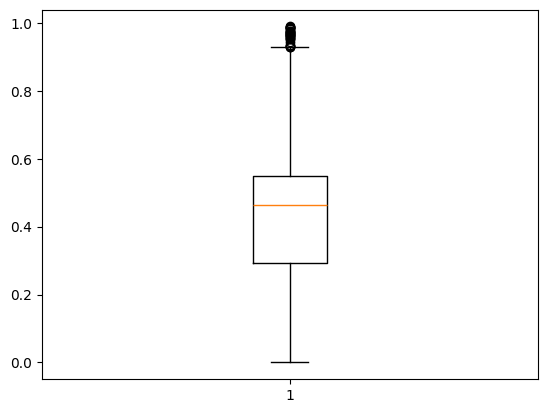

In [3]:
df = pd.read_csv("../outputs/analysis/data_quality/label_issues.csv")
df

print(f"Confidence in given labels statistics:")
plt.boxplot(df['confidence_in_given'], vert=True)




Confidence in suggested labels statistics:


{'whiskers': [<matplotlib.lines.Line2D at 0x16a739640>,
 'caps': [<matplotlib.lines.Line2D at 0x16a739b80>,
 'boxes': [<matplotlib.lines.Line2D at 0x16a7394c0>],
 'medians': [<matplotlib.lines.Line2D at 0x16a747100>],
 'fliers': [<matplotlib.lines.Line2D at 0x16a7473a0>],
 'means': []}

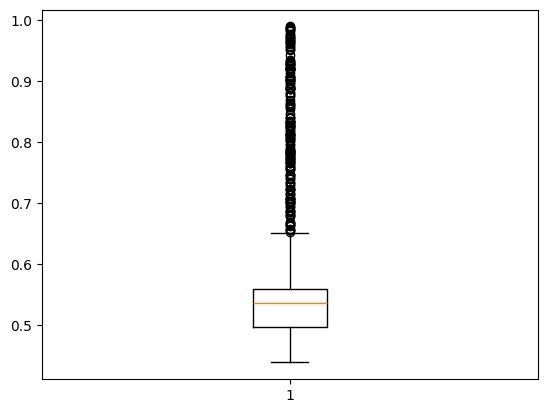

In [4]:
print(f"Confidence in suggested labels statistics:")
plt.boxplot(df['confidence_in_suggested'], vert=True)

Confidence in suggested-given labels statistics:
count    3722.000000
mean        0.121840
std         0.167532
min         0.000000
25%         0.000000
50%         0.000000
75%         0.251429
max         0.682886
Name: confidence_in_suggested_minus_given, dtype: float64


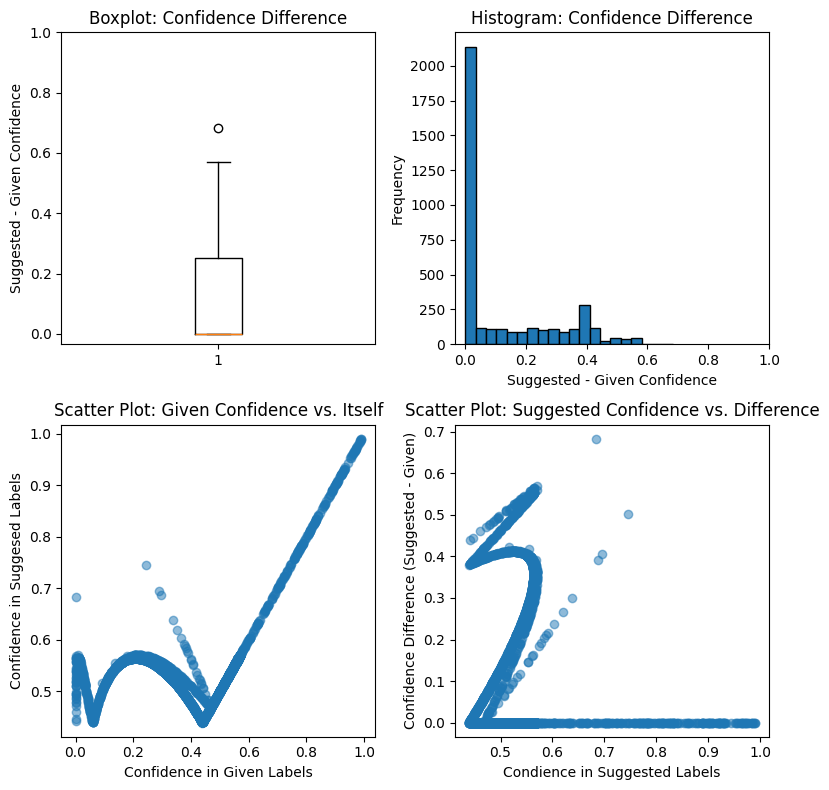

In [5]:

# Load the data
df = pd.read_csv('../outputs/analysis/data_quality/label_issues.csv')

# Calculate the difference
df['confidence_in_suggested_minus_given'] = df['confidence_in_suggested'] - df['confidence_in_given']

# Create a figure with two subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 8))

# Ticks every 0.2
ticks = np.arange(0, 1.1, 0.2)

# Boxplot
ax1.boxplot(df['confidence_in_suggested_minus_given'], vert=True)
ax1.set_yticks(ticks)
ax1.set_title('Boxplot: Confidence Difference')
ax1.set_ylabel('Suggested - Given Confidence')

# Histogram
ax2.hist(df['confidence_in_suggested_minus_given'], bins=20, edgecolor='black')
ax2.set_xticks(ticks)
ax2.set_title('Histogram: Confidence Difference')
ax2.set_xlabel('Suggested - Given Confidence')
ax2.set_ylabel('Frequency')

ax3.scatter(df["confidence_in_given"], df['confidence_in_suggested'], alpha=0.5)
ax3.set_xlabel("Confidence in Given Labels")
ax3.set_ylabel("Confidence in Suggesed Labels")
ax3.set_title("Scatter Plot: Given Confidence vs. Itself")

ax4.scatter(df["confidence_in_suggested"], df['confidence_in_suggested_minus_given'], alpha=0.5)
ax4.set_xlabel("Condience in Suggested Labels")
ax4.set_ylabel("Confidence Difference (Suggested - Given)")
ax4.set_title("Scatter Plot: Suggested Confidence vs. Difference")
plt.tight_layout()
#plt.savefig('confidence_diff_plots.png')

# Output some stats as requested in the user's print statement
stats = df['confidence_in_suggested_minus_given'].describe()
print(f"Confidence in suggested-given labels statistics:\n{stats}")



In [21]:
top_20_percent = int(0.15 * len(df))
top_diff_samples = df.sort_values('confidence_in_suggested_minus_given', ascending=False).head(top_20_percent)
top_diff_samples

df


,sample_index,measurement_id,given_label,suggested_label,confidence_in_given,confidence_in_suggested,confidence_in_suggested_minus_given
0,175,24409454,10,5,7.623509e-12,0.564127,0.564127
1,1241,24319685,4,8,2.632209e-08,0.557604,0.557604
2,2189,24601200,5,9,3.858338e-08,0.569482,0.569482
3,2021,24319683,5,8,3.769558e-06,0.460325,0.460321
4,363,24601328,10,7,1.332256e-05,0.526212,0.526198
...,...,...,...,...,...,...,...
3717,515,24376968,10,10,9.847602e-01,0.984760,0.000000
3718,514,24321592,10,10,9.870534e-01,0.987053,0.000000
3719,512,23992815,10,10,9.872548e-01,0.987255,0.000000
3720,14,24567936,1,1,9.893633e-01,0.989363,0.000000


# Visualisase suspicious samples

In [7]:

issues_to_review = top_diff_samples


# 2. Configuration: Update this path to where your images are stored
BASE_PATH = "../otolith_images" 

def get_image_path(row):
    # Adjust file extension (.jpg, .png, etc.) to match your data
    return os.path.join(BASE_PATH, str(int(row['given_label'])), f"{int(row['measurement_id'])}.jpg")

# 3. Viewer Logic
class LabelIssueViewer:
    def __init__(self, data):
        self.data = data
        self.index = 0
        self.output = widgets.Output()
        
        # Buttons
        self.btn_prev = widgets.Button(description="⬅️ Previous")
        self.btn_next = widgets.Button(description="Next ➡️")
        self.btn_prev.on_click(self.prev_image)
        self.btn_next.on_click(self.next_image)
        
    def show(self):
        # Layout: Buttons at the top, Image below
        controls = widgets.HBox([self.btn_prev, self.btn_next])
        display(controls, self.output)
        self.render()

    def render(self):
        with self.output:
            clear_output(wait=True)
            row = self.data.iloc[self.index]
            img_path = get_image_path(row)
            
            # Show Info
            print(f"Reviewing Issue {self.index + 1} of {len(self.data)}")
            print(f"Measurement ID: {row['measurement_id']}")
            print(f"Current Label: {row['given_label']} | Suggested: {row['suggested_label']}")
            
            # Plot Image
            if os.path.exists(img_path):
                img = plt.imread(img_path)
                plt.figure(figsize=(6, 6))
                plt.imshow(img)
                plt.title(f"Label: {row['given_label']} vs Suggestion: {row['suggested_label']}")
                plt.axis('off')
                plt.show()
            else:
                print(f"⚠️ Image not found at: {img_path}")

    def next_image(self, b):
        if self.index < len(self.data) - 1:
            self.index += 1
            self.render()

    def prev_image(self, b):
        if self.index > 0:
            self.index -= 1
            self.render()

# 4. Launch Viewer
viewer = LabelIssueViewer(issues_to_review)
viewer.show()

Output()

# Experimental Validation: Do Cleanlab Corrections Help?

Test whether replacing labels based on Cleanlab suggestions actually improves model performance.

**Hypothesis**: No improvement expected - most flags reflect biological ambiguity rather than clear errors.

In [8]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

import numpy as np
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score

from src.data import create_train_val_test_splits

In [53]:
# Configuration
EMBEDDINGS_PATH = "../outputs/embeddings/siglip2-so400m-14-384_embeddings.npz"  # Update this
RESULTS_JSON = "../outputs/results/shallow_siglip2/results.json"  # For alpha

N_EXPERIMENTS = 5
RANDOM_STATE = 42
CORRECTION_PCTS = [i/100 for i in range(0, 101, 5)]# Test 0%, 5%, 10%, 15%

CORRECTION_PCTS 

[0.0,
 0.05,
 0.1,
 0.15,
 0.2,
 0.25,
 0.3,
 0.35,
 0.4,
 0.45,
 0.5,
 0.55,
 0.6,
 0.65,
 0.7,
 0.75,
 0.8,
 0.85,
 0.9,
 0.95,
 1.0]

In [54]:
# Load embeddings
print("Loading embeddings...")
emb_data = np.load(EMBEDDINGS_PATH)
features = emb_data['features'] if 'features' in emb_data.files else emb_data['embeddings']
labels_original = emb_data['labels']
measurement_ids = emb_data.get('measurement_ids', None)
emb_data.close()

print(f"Features: {features.shape}, Labels: {labels_original.shape}")

# Augment embeddings with tabular features
METADATA_CSV = "../cod_otolith_age_final_with_quarters.csv"  # Update path
TABULAR_COLUMNS = ["length", "quarter_2", "quarter_3", "quarter_4"]

if Path(METADATA_CSV).exists():
    from src.data import augment_embeddings
    features = augment_embeddings(
        features, measurement_ids, METADATA_CSV, TABULAR_COLUMNS
    )
    print(f"Augmented features: {features.shape}")
else:
    print(f"Warning: Metadata CSV not found at {METADATA_CSV}, skipping augmentation")

# Load best alpha
import json
with open(RESULTS_JSON, 'r') as f:
    results_json = json.load(f)
best_alpha = np.mean([r["best_alpha"] for r in results_json["experiment_results"]])
print(f"Using alpha: {best_alpha:.3f}")

Loading embeddings...
Features: (8637, 1152), Labels: (8637,)
Augmented features: (8637, 1156)
Using alpha: 0.100


In [25]:
issues_sorted
#top_issues
len(labels_original)

8637

In [55]:
# Sort by confidence difference and create label variants
issues_sorted = df.sort_values('confidence_in_suggested_minus_given', ascending=False).copy()

label_variants = {}
for pct in CORRECTION_PCTS:
    labels_corrected = labels_original.copy()
    
    if pct >= 0:
        n_correct = int(pct * len(issues_sorted))
        top_issues = issues_sorted.head(n_correct)
        
        # Apply corrections
        for _, row in top_issues.iterrows():
            if measurement_ids is not None:
                idx = np.where(measurement_ids == row['measurement_id'])[0]
                if len(idx) > 0:
                    labels_corrected[idx[0]] = row['suggested_label']
        
        print(f"{pct*100:.0f}%: {n_correct} corrections, "
              f"mean conf_diff={top_issues['confidence_in_suggested_minus_given'].mean():.3f}")
    else:
        print("0%: Baseline (no corrections)")
    
    label_variants[pct] = labels_corrected

0%: 0 corrections, mean conf_diff=nan
5%: 186 corrections, mean conf_diff=0.503
10%: 372 corrections, mean conf_diff=0.456
15%: 558 corrections, mean conf_diff=0.434
20%: 744 corrections, mean conf_diff=0.412
25%: 930 corrections, mean conf_diff=0.386
30%: 1116 corrections, mean conf_diff=0.359
35%: 1302 corrections, mean conf_diff=0.330
40%: 1488 corrections, mean conf_diff=0.300
45%: 1674 corrections, mean conf_diff=0.271
50%: 1861 corrections, mean conf_diff=0.244
55%: 2047 corrections, mean conf_diff=0.222
60%: 2233 corrections, mean conf_diff=0.203
65%: 2419 corrections, mean conf_diff=0.187
70%: 2605 corrections, mean conf_diff=0.174
75%: 2791 corrections, mean conf_diff=0.162
80%: 2977 corrections, mean conf_diff=0.152
85%: 3163 corrections, mean conf_diff=0.143
90%: 3349 corrections, mean conf_diff=0.135
95%: 3535 corrections, mean conf_diff=0.128
100%: 3722 corrections, mean conf_diff=0.122


In [62]:
from sklearn.linear_model import Ridge  # Use Ridge, not RidgeClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Run experiments
results_by_variant = {}

for pct, labels_corrected in label_variants.items():
    print(f"\n{'='*50}\nTesting {pct*100:.0f}% corrections\n{'='*50}")
    
    # Create splits
    splits = create_train_val_test_splits(
        labels=labels_corrected,
        n_experiments=N_EXPERIMENTS,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1,
        random_state=RANDOM_STATE,
    )
    
    accs, accs_pm1, f1s = [], [], []
    
    for i, split in enumerate(splits):
        X_train = features[split.train_indices]
        y_train = labels_corrected[split.train_indices]
        X_test = features[split.test_indices]
        y_test = labels_corrected[split.test_indices]
        
        # Add sample weights
        sample_weights = compute_sample_weight("balanced", y_train)
        
        # Use Ridge (regressor) not RidgeClassifier
        model = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
        model.fit(X_train, y_train, sample_weight=sample_weights)
        
        # Round predictions to integers
        y_pred = np.round(model.predict(X_test)).astype(int)
        
        acc = accuracy_score(y_test, y_pred)
        acc_pm1 = np.mean(np.abs(y_test - y_pred) <= 1)
        f1 = f1_score(y_test, y_pred, average='macro')
        
        accs.append(acc)
        accs_pm1.append(acc_pm1)
        f1s.append(f1)

        
        print(f"Exp {i+1}: Acc={acc:.3f}, ±1={acc_pm1:.3f}, F1={f1:.3f}")
    
    results_by_variant[pct] = {
        'accuracy_mean': np.mean(accs),
        'accuracy_std': np.std(accs),
        'accuracy_pm1_mean': np.mean(accs_pm1),
        'accuracy_pm1_std': np.std(accs_pm1),
        'f1_mean': np.mean(f1s),
        'f1_std': np.std(f1s),
    }
    
    r = results_by_variant[pct]
    print(f"\nMean: Acc={r['accuracy_mean']*100:.2f}±{r['accuracy_std']*100:.2f}%, "
          f"±1={r['accuracy_pm1_mean']*100:.2f}±{r['accuracy_pm1_std']*100:.2f}%")


Testing 0% corrections
Exp 1: Acc=0.507, ±1=0.943, F1=0.424
Exp 2: Acc=0.507, ±1=0.953, F1=0.433
Exp 3: Acc=0.503, ±1=0.953, F1=0.473
Exp 4: Acc=0.515, ±1=0.962, F1=0.460
Exp 5: Acc=0.521, ±1=0.944, F1=0.446

Mean: Acc=51.06±0.64%, ±1=95.09±0.67%

Testing 5% corrections
Exp 1: Acc=0.519, ±1=0.958, F1=0.473
Exp 2: Acc=0.571, ±1=0.962, F1=0.464
Exp 3: Acc=0.560, ±1=0.966, F1=0.511
Exp 4: Acc=0.520, ±1=0.961, F1=0.431
Exp 5: Acc=0.524, ±1=0.957, F1=0.472

Mean: Acc=53.87±2.22%, ±1=96.09±0.32%

Testing 10% corrections
Exp 1: Acc=0.550, ±1=0.977, F1=0.481
Exp 2: Acc=0.581, ±1=0.973, F1=0.507
Exp 3: Acc=0.556, ±1=0.973, F1=0.552
Exp 4: Acc=0.574, ±1=0.973, F1=0.504
Exp 5: Acc=0.559, ±1=0.977, F1=0.467

Mean: Acc=56.39±1.17%, ±1=97.48±0.17%

Testing 15% corrections
Exp 1: Acc=0.583, ±1=0.976, F1=0.575
Exp 2: Acc=0.574, ±1=0.969, F1=0.526
Exp 3: Acc=0.578, ±1=0.975, F1=0.539
Exp 4: Acc=0.602, ±1=0.980, F1=0.540
Exp 5: Acc=0.584, ±1=0.975, F1=0.528

Mean: Acc=58.43±0.96%, ±1=97.48±0.37%

Testi

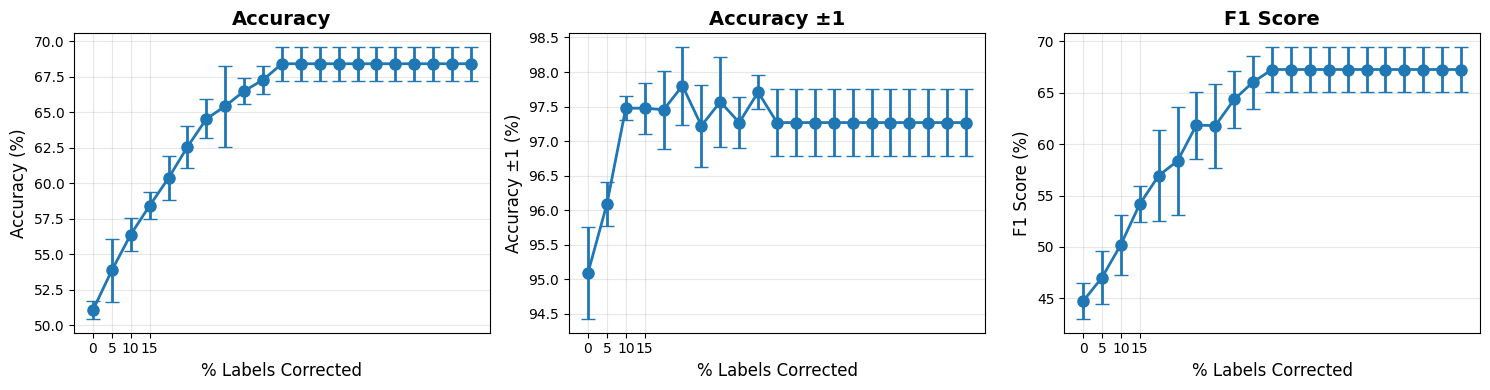

In [63]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pcts = list(results_by_variant.keys())
metrics = ['accuracy', 'accuracy_pm1', 'f1']
titles = ['Accuracy', 'Accuracy ±1', 'F1 Score']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    means = [results_by_variant[p][f'{metric}_mean'] * 100 for p in pcts]
    stds = [results_by_variant[p][f'{metric}_std'] * 100 for p in pcts]
    
    axes[idx].errorbar([p*100 for p in pcts], means, yerr=stds,
                       marker='o', capsize=5, linewidth=2, markersize=8)
    axes[idx].set_xlabel('% Labels Corrected', fontsize=12)
    axes[idx].set_ylabel(f'{title} (%)', fontsize=12)
    axes[idx].set_title(title, fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xticks([0, 5, 10, 15])

plt.tight_layout()
plt.savefig('../outputs/analysis/data_quality/correction_experiment.png', 
            dpi=300, bbox_inches='tight')
plt.show()

In [64]:
# Summary table
summary = []
baseline = results_by_variant[0.0]['accuracy_mean']

for pct in pcts:
    r = results_by_variant[pct]
    summary.append({
        'Corrections': f"{pct*100:.0f}%",
        'Accuracy': f"{r['accuracy_mean']*100:.2f}±{r['accuracy_std']*100:.2f}%",
        'Acc ±1': f"{r['accuracy_pm1_mean']*100:.2f}±{r['accuracy_pm1_std']*100:.2f}%",
        'F1': f"{r['f1_mean']*100:.2f}±{r['f1_std']*100:.2f}%",
        'Δ Acc': f"{(r['accuracy_mean']-baseline)*100:+.2f}%"
    })

summary_df = pd.DataFrame(summary)
print("\n" + "="*70)
print("EXPERIMENTAL VALIDATION RESULTS")
print("="*70)
print(summary_df.to_string(index=False))

# Interpretation
best_pct = max(pcts, key=lambda p: results_by_variant[p]['accuracy_mean'])
improvement = (results_by_variant[best_pct]['accuracy_mean'] - baseline) * 100

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if abs(improvement) < 0.5:
    print(f"\n✓ Hypothesis CONFIRMED: No meaningful change ({improvement:+.2f}%)")
    print("  Most flags reflect biological ambiguity, not labeling errors.")
elif improvement > 0.5:
    print(f"\n⚠ Hypothesis REJECTED: Improvement of {improvement:+.2f}%")
    print("  Some systematic errors were present. Investigate patterns.")
else:
    print(f"\n⚠ Performance DECLINED by {improvement:+.2f}%")
    print("  Corrections introduced noise - strongly supports ambiguity hypothesis.")


EXPERIMENTAL VALIDATION RESULTS
Corrections    Accuracy      Acc ±1          F1   Δ Acc
         0% 51.06±0.64% 95.09±0.67% 44.72±1.74%  +0.00%
         5% 53.87±2.22% 96.09±0.32% 47.02±2.55%  +2.80%
        10% 56.39±1.17% 97.48±0.17% 50.21±2.90%  +5.32%
        15% 58.43±0.96% 97.48±0.37% 54.16±1.78%  +7.36%
        20% 60.37±1.52% 97.45±0.56% 56.93±4.45%  +9.31%
        25% 62.57±1.47% 97.80±0.56% 58.37±5.22% +11.50%
        30% 64.54±1.37% 97.22±0.59% 61.85±3.25% +13.47%
        35% 65.44±2.86% 97.57±0.65% 61.80±4.08% +14.37%
        40% 66.50±0.91% 97.27±0.37% 64.36±2.79% +15.44%
        45% 67.29±0.98% 97.71±0.25% 66.04±2.58% +16.23%
        50% 68.43±1.18% 97.27±0.49% 67.26±2.19% +17.36%
        55% 68.43±1.18% 97.27±0.49% 67.26±2.19% +17.36%
        60% 68.43±1.18% 97.27±0.49% 67.26±2.19% +17.36%
        65% 68.43±1.18% 97.27±0.49% 67.26±2.19% +17.36%
        70% 68.43±1.18% 97.27±0.49% 67.26±2.19% +17.36%
        75% 68.43±1.18% 97.27±0.49% 67.26±2.19% +17.36%
        80% 68.

## Other Two


APPROACH 1: Corrected Training, Original Test Labels
Question: Does training on cleaner data improve real-world predictions?

Testing 0% corrections (Train only)
Exp 1: Acc=0.507, ±1=0.943, F1=0.513
Exp 2: Acc=0.507, ±1=0.953, F1=0.509
Exp 3: Acc=0.503, ±1=0.953, F1=0.506
Exp 4: Acc=0.515, ±1=0.962, F1=0.517
Exp 5: Acc=0.521, ±1=0.944, F1=0.522

Mean: Acc=51.06±0.64%, ±1=95.09±0.67%

Testing 5% corrections (Train only)
Exp 1: Acc=0.521, ±1=0.950, F1=0.526
Exp 2: Acc=0.520, ±1=0.954, F1=0.522
Exp 3: Acc=0.507, ±1=0.953, F1=0.508
Exp 4: Acc=0.549, ±1=0.962, F1=0.550
Exp 5: Acc=0.523, ±1=0.951, F1=0.525

Mean: Acc=52.38±1.36%, ±1=95.39±0.41%

Testing 10% corrections (Train only)
Exp 1: Acc=0.520, ±1=0.950, F1=0.524
Exp 2: Acc=0.523, ±1=0.957, F1=0.525
Exp 3: Acc=0.509, ±1=0.957, F1=0.511
Exp 4: Acc=0.544, ±1=0.965, F1=0.545
Exp 5: Acc=0.527, ±1=0.954, F1=0.529

Mean: Acc=52.45±1.13%, ±1=95.67±0.50%

Testing 15% corrections (Train only)
Exp 1: Acc=0.522, ±1=0.948, F1=0.527
Exp 2: Acc=0.53

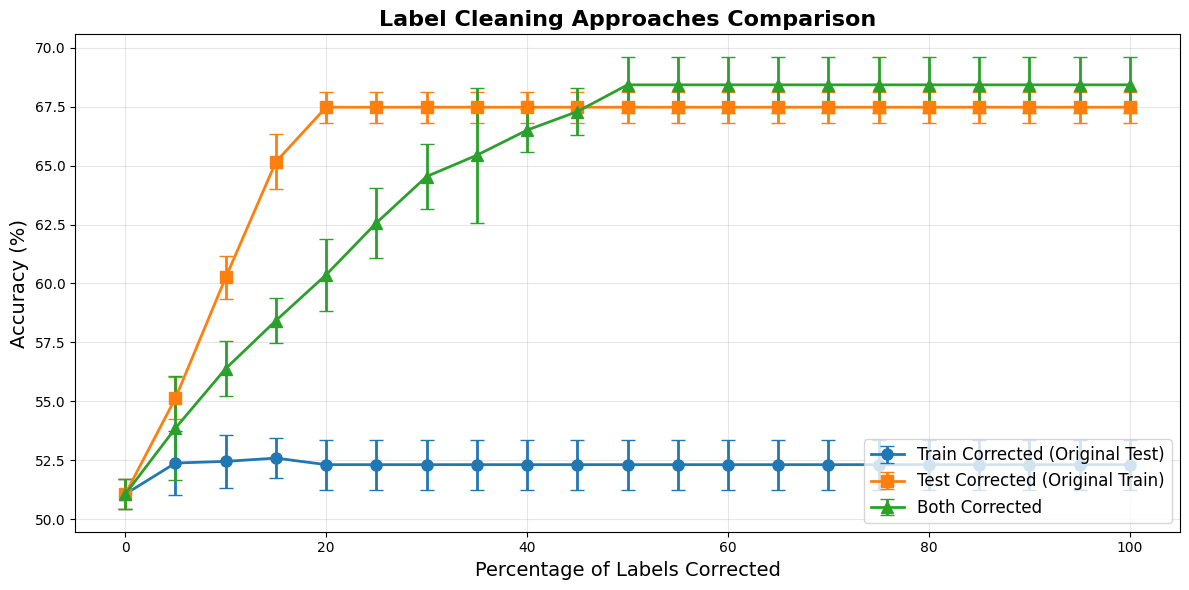


Plot saved to: ../outputs/analysis/data_quality/three_approaches_comparison.png

INTERPRETATION

Baseline (no corrections): 51.06%

Best results at 15% corrections:
  Approach 1 (Train corrected):  52.59% (+1.53%)
  Approach 2 (Test corrected):   65.16% (+14.10%)
  Approach 3 (Both corrected):   58.43% (+7.36%)

What this tells us:
  • Test label noise: ~14.1% of errors due to incorrect test labels
  • Training value: ~1.5% improvement from cleaner training data
  • Total potential: ~7.4% improvement with fully cleaned dataset
  • Synergy: -8.3% from interaction effects


In [66]:
# ============================================================================
# Approach 1: Correct Training Only, Test on Original Labels
# ============================================================================
print("\n" + "="*70)
print("APPROACH 1: Corrected Training, Original Test Labels")
print("Question: Does training on cleaner data improve real-world predictions?")
print("="*70)

results_train_corrected = {}

for pct in CORRECTION_PCTS:
    print(f"\n{'='*50}\nTesting {pct*100:.0f}% corrections (Train only)\n{'='*50}")
    
    # Create splits using ORIGINAL labels
    splits = create_train_val_test_splits(
        labels=labels_original,
        n_experiments=N_EXPERIMENTS,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1,
        random_state=RANDOM_STATE,
    )
    
    accs, accs_pm1, f1s = [], [], []
    
    for i, split in enumerate(splits):
        X_train = features[split.train_indices]
        y_train = labels_original[split.train_indices].copy()
        X_test = features[split.test_indices]
        y_test = labels_original[split.test_indices]  
        
        if pct > 0:
            # Only correct TRAINING labels
            n_correct = int(pct * len(labels_original))
            top_issues = issues_sorted.head(n_correct)
            
            # Get measurement IDs for this train split
            train_measurement_ids = measurement_ids[split.train_indices]
            
            # Apply corrections only to training set
            for _, row in top_issues.iterrows():
                train_idx = np.where(train_measurement_ids == row['measurement_id'])[0]
                if len(train_idx) > 0:
                    y_train[train_idx[0]] = row['suggested_label']
        
        # Train with sample weights
        sample_weights = compute_sample_weight("balanced", y_train)
        model = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
        model.fit(X_train, y_train, sample_weight=sample_weights)
        
        # Test on ORIGINAL labels
        y_pred = np.round(model.predict(X_test)).astype(int)
        
        acc = accuracy_score(y_test, y_pred)
        acc_pm1 = np.mean(np.abs(y_test - y_pred) <= 1)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        accs.append(acc)
        accs_pm1.append(acc_pm1)
        f1s.append(f1)
        
        print(f"Exp {i+1}: Acc={acc:.3f}, ±1={acc_pm1:.3f}, F1={f1:.3f}")
    
    results_train_corrected[pct] = {
        'accuracy_mean': np.mean(accs),
        'accuracy_std': np.std(accs),
        'accuracy_pm1_mean': np.mean(accs_pm1),
        'accuracy_pm1_std': np.std(accs_pm1),
        'f1_mean': np.mean(f1s),
        'f1_std': np.std(f1s),
    }
    
    r = results_train_corrected[pct]
    print(f"\nMean: Acc={r['accuracy_mean']*100:.2f}±{r['accuracy_std']*100:.2f}%, "
          f"±1={r['accuracy_pm1_mean']*100:.2f}±{r['accuracy_pm1_std']*100:.2f}%")

# ============================================================================
# Approach 2: Original Training, Corrected Test Labels
# ============================================================================
print("\n" + "="*70)
print("APPROACH 2: Original Training, Corrected Test Labels")
print("Question: How accurate were the original test labels?")
print("="*70)

results_test_corrected = {}

for pct in CORRECTION_PCTS:
    print(f"\n{'='*50}\nTesting {pct*100:.0f}% corrections (Test only)\n{'='*50}")
    
    # Create splits using ORIGINAL labels
    splits = create_train_val_test_splits(
        labels=labels_original,
        n_experiments=N_EXPERIMENTS,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1,
        random_state=RANDOM_STATE,
    )
    
    accs, accs_pm1, f1s = [], [], []
    
    for i, split in enumerate(splits):
        X_train = features[split.train_indices]
        y_train = labels_original[split.train_indices]  # KEEP ORIGINAL
        X_test = features[split.test_indices]
        y_test = labels_original[split.test_indices].copy()
        
        if pct > 0:
            # Only correct TEST labels
            n_correct = int(pct * len(labels_original))
            top_issues = issues_sorted.head(n_correct)
            
            # Get measurement IDs for this test split
            test_measurement_ids = measurement_ids[split.test_indices]
            
            # Apply corrections only to test set
            for _, row in top_issues.iterrows():
                test_idx = np.where(test_measurement_ids == row['measurement_id'])[0]
                if len(test_idx) > 0:
                    y_test[test_idx[0]] = row['suggested_label']
        
        # Train on ORIGINAL labels with sample weights
        sample_weights = compute_sample_weight("balanced", y_train)
        model = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
        model.fit(X_train, y_train, sample_weight=sample_weights)
        
        # Test on CORRECTED labels
        y_pred = np.round(model.predict(X_test)).astype(int)
        
        acc = accuracy_score(y_test, y_pred)
        acc_pm1 = np.mean(np.abs(y_test - y_pred) <= 1)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        accs.append(acc)
        accs_pm1.append(acc_pm1)
        f1s.append(f1)
        
        print(f"Exp {i+1}: Acc={acc:.3f}, ±1={acc_pm1:.3f}, F1={f1:.3f}")
    
    results_test_corrected[pct] = {
        'accuracy_mean': np.mean(accs),
        'accuracy_std': np.std(accs),
        'accuracy_pm1_mean': np.mean(accs_pm1),
        'accuracy_pm1_std': np.std(accs_pm1),
        'f1_mean': np.mean(f1s),
        'f1_std': np.std(f1s),
    }
    
    r = results_test_corrected[pct]
    print(f"\nMean: Acc={r['accuracy_mean']*100:.2f}±{r['accuracy_std']*100:.2f}%, "
          f"±1={r['accuracy_pm1_mean']*100:.2f}±{r['accuracy_pm1_std']*100:.2f}%")

# ============================================================================
# Compare All Three Approaches
# ============================================================================
print("\n" + "="*70)
print("COMPARISON: All Three Approaches")
print("="*70)

comparison_data = []
for pct in CORRECTION_PCTS:
    comparison_data.append({
        'Corrections': f"{pct*100:.0f}%",
        'Approach 1: Train Corrected': f"{results_train_corrected[pct]['accuracy_mean']*100:.2f}±{results_train_corrected[pct]['accuracy_std']*100:.2f}%",
        'Approach 2: Test Corrected': f"{results_test_corrected[pct]['accuracy_mean']*100:.2f}±{results_test_corrected[pct]['accuracy_std']*100:.2f}%",
        'Approach 3: Both Corrected': f"{results_by_variant[pct]['accuracy_mean']*100:.2f}±{results_by_variant[pct]['accuracy_std']*100:.2f}%",
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

pcts_plot = [p*100 for p in CORRECTION_PCTS]

# Approach 1: Train corrected
means1 = [results_train_corrected[p]['accuracy_mean']*100 for p in CORRECTION_PCTS]
stds1 = [results_train_corrected[p]['accuracy_std']*100 for p in CORRECTION_PCTS]
ax.errorbar(pcts_plot, means1, yerr=stds1, marker='o', capsize=5, 
            linewidth=2, markersize=8, label='Train Corrected (Original Test)')

# Approach 2: Test corrected
means2 = [results_test_corrected[p]['accuracy_mean']*100 for p in CORRECTION_PCTS]
stds2 = [results_test_corrected[p]['accuracy_std']*100 for p in CORRECTION_PCTS]
ax.errorbar(pcts_plot, means2, yerr=stds2, marker='s', capsize=5, 
            linewidth=2, markersize=8, label='Test Corrected (Original Train)')

# Approach 3: Both corrected
means3 = [results_by_variant[p]['accuracy_mean']*100 for p in CORRECTION_PCTS]
stds3 = [results_by_variant[p]['accuracy_std']*100 for p in CORRECTION_PCTS]
ax.errorbar(pcts_plot, means3, yerr=stds3, marker='^', capsize=5, 
            linewidth=2, markersize=8, label='Both Corrected')

ax.set_xlabel('Percentage of Labels Corrected', fontsize=14)
ax.set_ylabel('Accuracy (%)', fontsize=14)
ax.set_title('Label Cleaning Approaches Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/analysis/data_quality/three_approaches_comparison.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\nPlot saved to: ../outputs/analysis/data_quality/three_approaches_comparison.png")

# ============================================================================
# Interpretation
# ============================================================================
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

baseline = results_by_variant[0.0]['accuracy_mean'] * 100
best_pct = max(CORRECTION_PCTS, key=lambda p: results_train_corrected[p]['accuracy_mean'])

train_corr_improvement = (results_train_corrected[best_pct]['accuracy_mean'] * 100) - baseline
test_corr_improvement = (results_test_corrected[best_pct]['accuracy_mean'] * 100) - baseline
both_corr_improvement = (results_by_variant[best_pct]['accuracy_mean'] * 100) - baseline

print(f"\nBaseline (no corrections): {baseline:.2f}%")
print(f"\nBest results at {best_pct*100:.0f}% corrections:")
print(f"  Approach 1 (Train corrected):  {results_train_corrected[best_pct]['accuracy_mean']*100:.2f}% ({train_corr_improvement:+.2f}%)")
print(f"  Approach 2 (Test corrected):   {results_test_corrected[best_pct]['accuracy_mean']*100:.2f}% ({test_corr_improvement:+.2f}%)")
print(f"  Approach 3 (Both corrected):   {results_by_variant[best_pct]['accuracy_mean']*100:.2f}% ({both_corr_improvement:+.2f}%)")

print("\nWhat this tells us:")
print(f"  • Test label noise: ~{test_corr_improvement:.1f}% of errors due to incorrect test labels")
print(f"  • Training value: ~{train_corr_improvement:.1f}% improvement from cleaner training data")
print(f"  • Total potential: ~{both_corr_improvement:.1f}% improvement with fully cleaned dataset")
print(f"  • Synergy: {both_corr_improvement - train_corr_improvement - test_corr_improvement:.1f}% from interaction effects")